In [3]:
#1 KM DATA
###########################################################################################

#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

#Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
netCDF=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
true_time=netCDF['time']
parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc') #***
times=netCDF['time'].values/(1e9 * 60); times=times.astype(float);

#Restricts the timesteps of the data from timesteps0 to 140
netCDF=netCDF.isel(time=np.arange(0,140+1))
# parcel=parcel.isel(time=np.arange(0,140+1))

res='1km'

In [61]:
# #250 M DATA
# ###########################################################################################

# #Loading in Packages and Data

# #Importing Packages
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.colors as colors
# import matplotlib.ticker as ticker
# import matplotlib.cm as cm
# from matplotlib.colors import Normalize
# from matplotlib.ticker import MaxNLocator
# from matplotlib.ticker import ScalarFormatter
# import matplotlib.gridspec as gridspec
# import xarray as xr
# import os; import time
# import pickle
# import h5py
# ###############################################################
# def coefs(coefficients,degree):
#     coef=coefficients
#     coefs=""
#     for n in range(degree, -1, -1):
#         string=f"({coefficients[len(coef)-(n+1)]:.1e})"
#         coefs+=string + f"x^{n}"
#         if n != 0:
#             coefs+=" + "
#     return coefs
# ###############################################################

# #Importing Model Data
# check=False
# dir='/home/air673/koa_scratch/'

# netCDF=xr.open_dataset(dir+'cm1out.nc') #***
# res='250m'

In [62]:
def load_vars(data):
    print('PRESSURE VARIABLES'); ################################# PRESSURE VARIABLES
    p0=1e5
    P=data['prs'].data

   # print('THERMODYNAMICS'); ################################# THERMODYNAMICS
    Rd=287.04
    # Rv=461.5
    Cpd=1005.7 #+-2.5
    Cpv=1870 #+-25
    Cpl=4190 #+-30
    Lv0=2.501e6
    def Lv(T): #Kirchoff's formula L_i,ii= L_i,ii0+(Cpii-Cpi)*(T-273.15)
        Llv=Lv0+(Cpv-Cpl)*(T-273.15) #should it be Cpl. is Cl the same?***
        return Llv
    
    # print('TEMPERATURE'); ################################# TEMPERATURE
    theta=data['th'].data
    T=theta*(P/p0)**(Rd/Cpd)

    # print('Specific Humidity'); ################################# Specific Humidity
    rv=data['qv'].data
    q=rv/(1+rv)

    ################################# Geopotential Height
    Nz,Ny,Nx=len(netCDF['zh']),len(netCDF['yh']),len(netCDF['xh'])
    zh_values=data['zh'].values*1000
    Z=np.broadcast_to(zh_values[:, np.newaxis, np.newaxis], (Nz, Ny, Nx))
    g=9.81
    gZ=g*Z
    
    return Cpd,T,Lv,q,gZ

In [63]:
def make_MSE(Cpd,T,q,gZ):
    # 3e2*1e3 + 2e6*5e-3 + 10 * 1e4 #~ 310000-410000 J/kg
    MSE=Cpd*T+Lv(T)*q+gZ
    return MSE

In [73]:
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
def initiate_array():
    # Define array dimensions (adjust based on your netCDF)
    t_size = len(netCDF['time'])  # Number of timesteps
    z_size = len(netCDF['zh'])    # Number of vertical levels
    y_size = len(netCDF['yh'])    # Number of y-axis points
    x_size = len(netCDF['xh'])    # Number of x-axis points
    
    with h5py.File(dir2 + 'Variable_Calculation/' + 'MSE'+f'_{res}'+'.h5', 'a') as f:
        # Check if the dataset 'theta_e' already exists
        if 'MSE' not in f:
            # Create a dataset with the full size for all time steps (initially empty)
            f.create_dataset('MSE', 
                             (t_size, z_size, y_size, x_size),  # Full size for all timesteps
                             maxshape=(None, z_size, y_size, x_size),  # Unlimited timesteps (can grow along time dimension)
                             dtype='float64', 
                             chunks=(1, z_size, y_size, x_size))  # Chunks for time axis to allow resizing

            
def add_timestep_at_index(timestep_data, index):
    with h5py.File(dir2 + 'Variable_Calculation/' + 'MSE'+f'_{res}'+'.h5', 'a') as f:
        # Access the existing dataset 'MSE'
        dataset = f['MSE']
        
        # Assign the new timestep data at the specified index
        dataset[index] = timestep_data

In [ ]:
#RUNNING

In [ ]:
#MAKING ARRAY TO STORE THETA_E
initiate_array()

#CALCULATING AND APPENDING TO DATA EACH TIMESTEP
for t in range(len(netCDF['time'])):
    if np.mod(t,1)==0: print(f'Current time {t}')
    data=netCDF.isel(time=t)
    [Cpd,T,Lv,q,gZ] = load_vars(data)
    MSE=make_MSE(Cpd,T,q,gZ)
    add_timestep_at_index(MSE, t)


#Fast for 1KM, longer for 250m

In [82]:
# #READING FINAL OUTPUT
# with h5py.File(dir2+ 'Variable_Calculation/' + 'MSE_1km.h5', 'a') as f:
#     # Access the existing dataset 'MSE'
#     dataset = f['MSE'][:]

Text(0.5, 1.0, 'MSE at t = 50, z = 30 m')

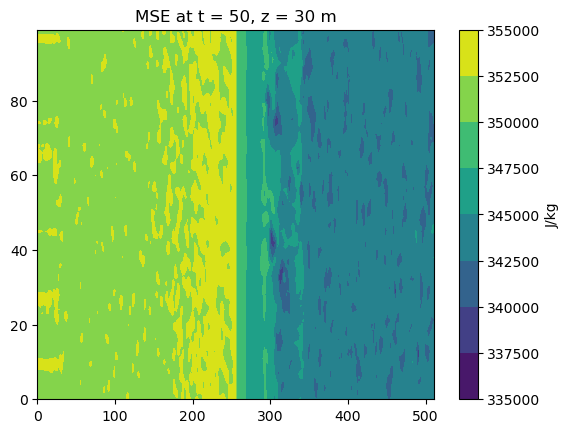

In [83]:
# plt.contourf(dataset[50,0])
# plt.colorbar(label='J/kg')
# plt.title("MSE at t = 50, z = 30 m")